## Introduction: Keynes, Friedman, Modigliani

[![badge](https://img.shields.io/badge/Launch%20using%20-Econ--ARK-blue)](https://econ-ark.org/materials/keynesfriedmanmodigliani#launch)

In [1]:
# Some initial setup
from HARK.ConsumptionSaving.ConsIndShockModel import PerfForesightConsumerType
import pandas_datareader.data as web
import statsmodels.formula.api as sm
import scipy.stats as stats
import datetime as dt
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-darkgrid")
palette = plt.get_cmap("Dark2")


pd.core.common.is_list_like = pd.api.types.is_list_like

### 1. The Keynesian consumption function

Keynes:
1. "The amount of aggregate consumption mainly depends on the amount of aggregate income."
1. It is a "fundamental psychological rule ... that when ... real income increases ... consumption [will increase], but by less than the increase in income."
1. More generally, "as a rule, a greater proportion of income ... is saved as real income increases."

This can be formalized as:

$
\begin{eqnarray}
c_t & = &  a_0 + a_{1}y_t
\\ c_t - c_{t-1} & = & a_{1}(y_t - y_{t-1})
\end{eqnarray}
$

for $a_0 > 0, a_1 < 1$


#### The Keynesian Consumption Function

In [2]:
class KeynesianConsumer:
    """
    This class represents consumers that behave according to a
    Keynesian consumption function, representing them as a
    special case of HARK's PerfForesightConsumerType

    Methods:
    - cFunc: computes consumption/permanent income
             given total income/permanent income.
    """

    def __init__(self):
        Keynesian = (
            PerfForesightConsumerType()
        )  # set up a consumer type and use default parameteres
        Keynesian.cycles = 0  # Make this type have an infinite horizon
        Keynesian.DiscFac = 0.05
        Keynesian.PermGroFac = [0.7]

        Keynesian.solve()  # solve the consumer's problem
        Keynesian.unpack("cFunc")  # unpack the consumption function

        self.cFunc = Keynesian.solution[0].cFunc
        self.a0 = self.cFunc(0)
        self.a1 = self.cFunc(1) - self.cFunc(0)

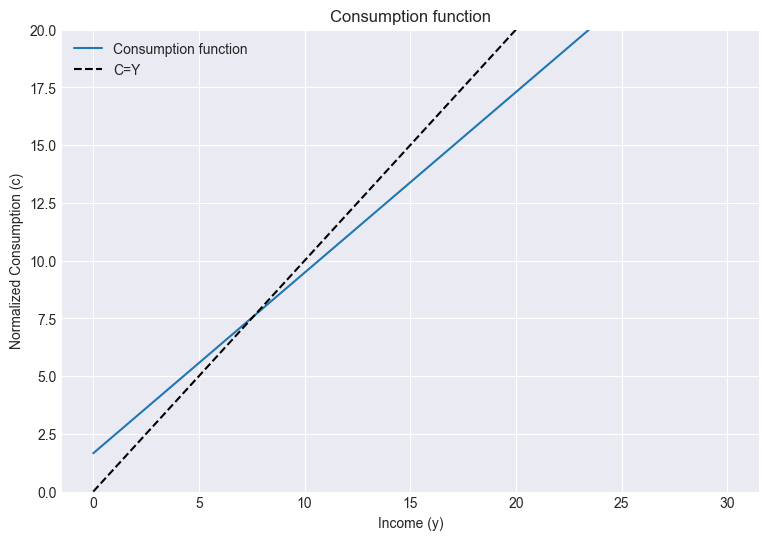

In [3]:
# Plot cFunc(Y)=Y against the Keynesian consumption function
# Deaton-Friedman consumption function is a special case of perfect foresight model

# We first create a Keynesian consumer
KeynesianExample = KeynesianConsumer()

# and then plot its consumption function
income = np.linspace(0, 30, 20)  # pick some income points
plt.figure(figsize=(9, 6))
plt.plot(
    income, KeynesianExample.cFunc(income), label="Consumption function"
)  # plot income versus the consumption
plt.plot(income, income, "k--", label="C=Y")
plt.title("Consumption function")
plt.xlabel("Income (y)")
plt.ylabel("Normalized Consumption (c)")
plt.ylim(0, 20)
plt.legend()
plt.show()

In [4]:
# This looks like the first of the three equations, consumption as a linear function of income!
# This means that even in a microfounded model (that HARK provides), the consumption function can match Keynes reduced form
# prediction (given the right parameterization).

# We can even find a_0 and a_1
a_0 = KeynesianExample.a0
a_1 = KeynesianExample.a1
print("a_0 is {:.2f}".format(a_0))
print("a_1 is {:.2f}".format(a_1))

a_0 is 1.66
a_1 is 0.78


#### The Keynesian consumption function: Evidence

Aggregate Data:

Long-term time-series estimates: $a_0$ close to zero, $a_1$ close to 1 (saving rate stable over time - Kuznets).<br>
Short-term aggregate time-series estimates of change in consumption on change in income find $a_1 << 1$.<br>
$c_t = a_0 + a_{1}y_t + a_{2}c_{t-1}$ finds significant $a_2$, near 1.

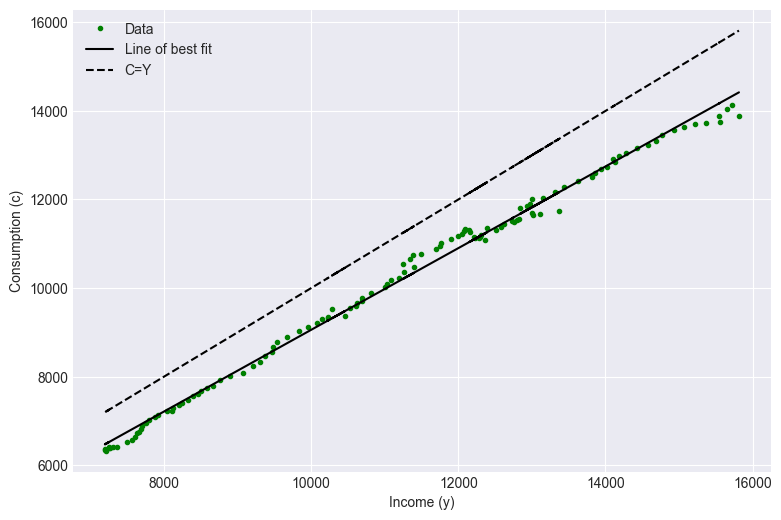

a_0 is -165.84
a_1 is 0.92


In [5]:
# Lets have a look at some aggregate data

sdt = dt.datetime(1990, 1, 1)  # set startdate
edt = dt.datetime(2020, 1, 1)  # set end date
df = web.DataReader(
    ["PCECC96", "DPIC96"], "fred", sdt, edt
)  # import the data from Fred
# Plot the data
plt.figure(figsize=(9, 6))
plt.plot(df.DPIC96, df.PCECC96, "go", markersize=3.0, label="Data")
slope, intercept, r_value, p_value, std_err = stats.linregress(df.DPIC96, df.PCECC96)
plt.plot(df.DPIC96, intercept + slope * df.DPIC96, "k-", label="Line of best fit")
plt.plot(df.DPIC96, df.DPIC96, "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Consumption (c)")
plt.legend()
plt.show()

print("a_0 is {:.2f}".format(intercept))
print("a_1 is {:.2f}".format(slope))

Text(0, 0.5, 'Consumption (c)')

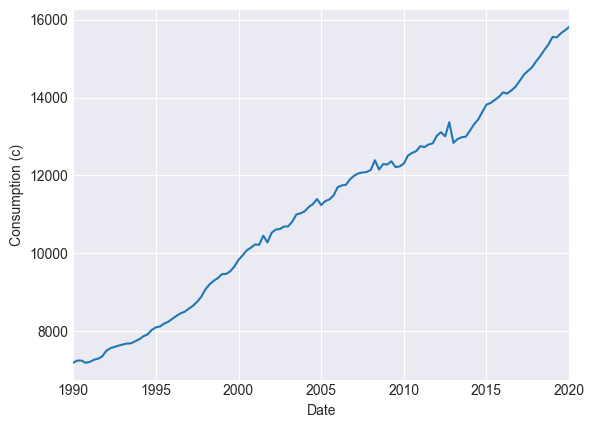

In [6]:
# However, our consumption data is [non-stationary](https://www.reed.edu/economics/parker/312/tschapters/S13_Ch_4.pdf) and this drives the previous
# estimate.
df.DPIC96.plot()
plt.xlabel("Date")
plt.ylabel("Consumption (c)")

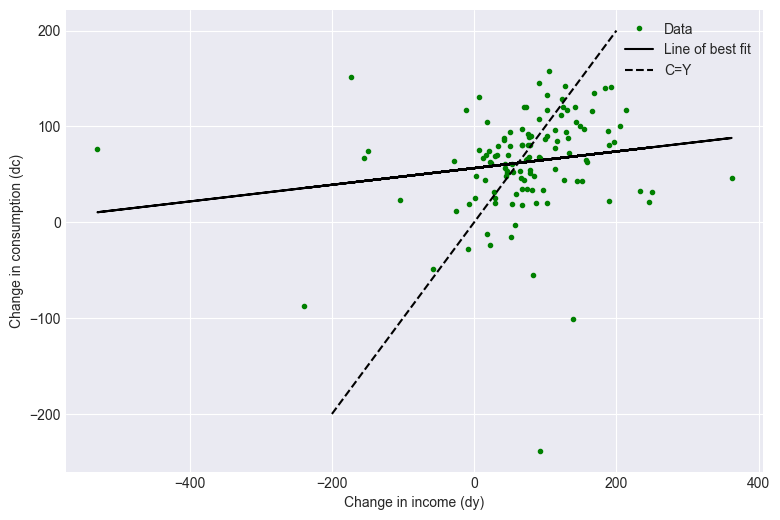

a_1 is 0.09


In [7]:
# Lets use our second equation to try to find an estimate of a_1

df_diff = df.diff()  # create dataframe of differenced values

# Plot the data
plt.figure(figsize=(9, 6))
plt.plot(df_diff.DPIC96, df_diff.PCECC96, "go", markersize=3.0, label="Data")
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_diff.DPIC96[1:], df_diff.PCECC96[1:]
)  # find line of best fit
plt.plot(
    df_diff.DPIC96[1:],
    intercept + slope * df_diff.DPIC96[1:],
    "k-",
    label="Line of best fit",
)
plt.plot(np.array([-200, 200]), np.array([-200, 200]), "k--", label="C=Y")
plt.xlabel("Change in income (dy)")
plt.ylabel("Change in consumption (dc)")
plt.legend()
plt.show()

print("a_1 is {:.2f}".format(slope))

a_1 is now much lower, as we expected

### Household Data:

Cross-section plots of consumption and income: very large and significant $a_0$, $a_1$ maybe 0.5. <br>

Further facts:
1. Black households save more than whites at a given income level.<br>
0. By income group:
   * low-income: Implausibly large dissaving (spend 2 or 3 times income)
   * high-income: Remarkably high saving

### 2. Duesenberry

Habit formation may explain why $c_{t-1}$ affects $c_t$.<br>
Relative Income Hypothesis suggests that you compare your consumption to consumption of ‘peers’.<br>
May explain high saving rates of Black HHs.<br>

Problems with Duesenberry: <br>
No budget constraint<br>
No serious treatment of intertemporal nature of saving

#### Dusenberry: Evidence

In [8]:
# Even if we control for income, past consumption seems to be significantly related to current consumption

df_habit = df.copy()
df_habit.columns = ["cons", "inc"]
df_habit["cons_m1"] = df.PCECC96.shift()
df_habit.dropna()

result = sm.ols(formula="cons ~ inc + cons_m1", data=df_habit.dropna()).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   cons   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.057e+05
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          2.81e-191
Time:                        19:09:27   Log-Likelihood:                -648.25
No. Observations:                 120   AIC:                             1303.
Df Residuals:                     117   BIC:                             1311.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     57.9131     23.968      2.416      0.017      10.445     105.381
inc            0.0164      0.029      0.569      0.570      -0.041       0.074
cons_m1        0.9823      0.031     31.473      0.000       0.920       1.044
==============================================================================
Omnibus:                       68.987   Durbin-Watson:                   1.098
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              387.454
Skew:                          -1.901   Prob(JB):                     7.33e-85
Kurtosis:                      10.939   Cond. No.                     7.44e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.44e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
# The coefficient on lagged consumption is very significant.
# But regression may be statistically problematic for the usual [non-stationarity](https://towardsdatascience.com/stationarity-in-time-series-analysis-90c94f27322) reasons.

### 3. Friedman's Permanent Income Hypothesis

$$c = p + u$$
$$y = p + v$$

We can try to test this theory across households. If we run a regression of the form:
$$c_i = a_0 + a_{1}y_{i} + u_{i}$$

And if Friedman is correct, and the "true" coefficient on permanent income $p$ is 1, then the coefficient on $y$ will be:
$$a_1 = \frac{s^2_{p}}{(s^2_{v} + s^2_{p})}$$

#### Friedman's Permanent Income Hypothesis

We begin by creating a class that class implements the Friedman PIH consumption function as a special case of the [Perfect Foresight CRRA](http://www.econ2.jhu.edu/people/ccarroll/courses/choice/lecturenotes/consumption/PerfForesightCRRA) model.

As discussed in the lecture notes, it is often convenient to represent this type of models in variables that are normalized by permanent income. That is the case for the [HARK](https://github.com/econ-ark/HARK/) tools that we use below in the definition of our consumer. Therefore, the consumption function will expect
\begin{equation*}
y_{i,t} = \frac{Y_{i,t}}{P_{i,t}}
\end{equation*}
and compute
\begin{equation*}
c_{i,t} = \frac{C_{i,t}}{P_{i,t}}.
\end{equation*}

Therefore, to find consumption at a total level of income $Y$, we will use $\texttt{P} \times \texttt{cFunc(Y/P)}$.

In [10]:
class FriedmanPIHConsumer:
    """
    This class represents consumers that behave according to
    Friedman's permanent income hypothesis, representing them as a
    special case of HARK's PerfForesightConsumerType

    Methods:
    - cFunc: computes consumption/permanent income
             given total income/permanent income.
    """

    def __init__(self, Rfree=1.001, CRRA=2):
        FriedmanPIH = (
            PerfForesightConsumerType()
        )  # set up a consumer type and use default parameteres
        FriedmanPIH.cycles = 0  # Make this type have an infinite horizon
        FriedmanPIH.DiscFac = 1 / Rfree
        FriedmanPIH.Rfree = [Rfree]
        FriedmanPIH.LivPrb = [1.0]
        FriedmanPIH.PermGroFac = [1.0]
        FriedmanPIH.CRRA = CRRA
        FriedmanPIH.solve()  # solve the consumer's problem
        FriedmanPIH.unpack("cFunc")  # unpack the consumption function

        self.cFunc = FriedmanPIH.solution[0].cFunc

Now, think of a consumer that has a permanent income of 1. What will be his consumption at different levels of total observed income?

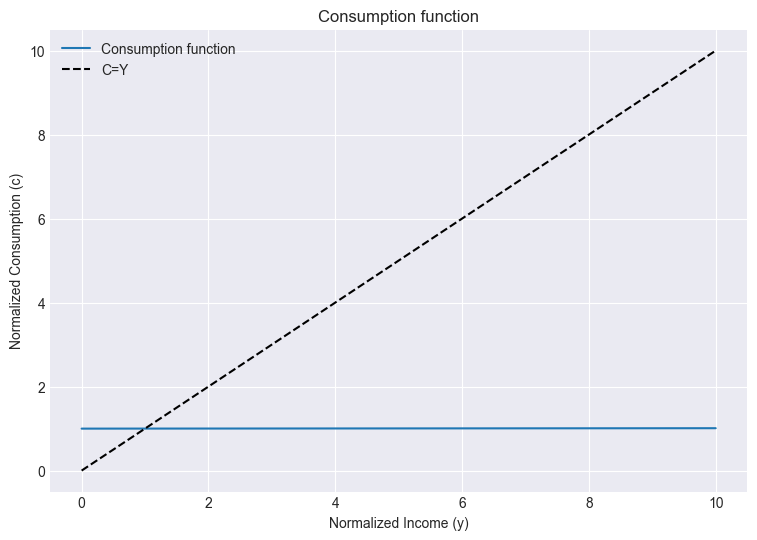

In [11]:
# We can now create a PIH consumer
PIHexample = FriedmanPIHConsumer()

# Plot the perfect foresight consumption function
income = np.linspace(0, 10, 20)  # pick some income points
plt.figure(figsize=(9, 6))
plt.plot(
    income, PIHexample.cFunc(income), label="Consumption function"
)  # plot income versus the consumption
plt.plot(income, income, "k--", label="C=Y")
plt.title("Consumption function")
plt.xlabel("Normalized Income (y)")
plt.ylabel("Normalized Consumption (c)")
plt.legend()
plt.show()

We can see that regardless of the income our agent receives, they consume their permanent income, which is normalized to 1.

We can also draw out some implications of the PIH that we can then test with evidence

If we look at HH's who have very similar permanent incomes, we should get a small estimate of $a_1$, because $s^2_v$ is large relative to $s^2_p$.

Lets simulate this using our consumer.

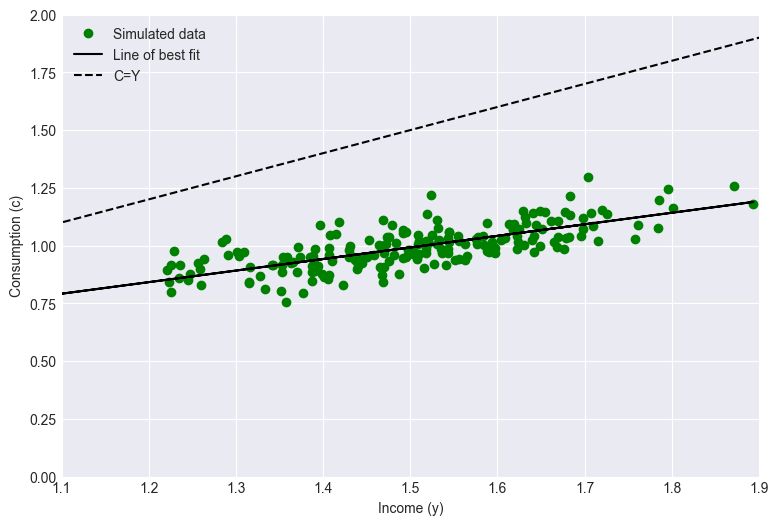

a_0 is 0.24
a_1 is 0.50


In [12]:
# Permanent income has the same variance
# as transitory income.

perm_inc = np.random.normal(1.0, 0.1, 200)
trans_inc = np.random.normal(0.5, 0.1, 200)

total_inc = perm_inc + trans_inc

slope, intercept, r_value, p_value, std_err = stats.linregress(
    total_inc, PIHexample.cFunc(total_inc / perm_inc) * perm_inc
)

plt.figure(figsize=(9, 6))
plt.plot(
    total_inc, PIHexample.cFunc(total_inc) * perm_inc, "go", label="Simulated data"
)
plt.plot(total_inc, intercept + slope * total_inc, "k-", label="Line of best fit")
plt.plot(np.linspace(1, 2, 5), np.linspace(1, 2, 5), "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Consumption (c)")
plt.legend()
plt.ylim(0, 2)
plt.xlim(1.1, 1.9)
plt.show()

print("a_0 is {:.2f}".format(intercept))
print("a_1 is {:.2f}".format(slope))

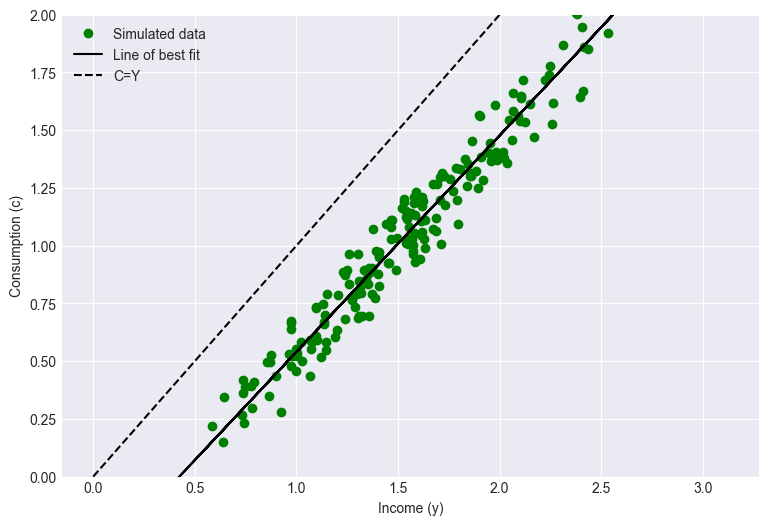

a_0 is -0.40
a_1 is 0.94


In [13]:
# Permanent income with higher variance

perm_inc = np.random.normal(1.0, 0.5, 200)
trans_inc = np.random.normal(0.5, 0.1, 200)

total_inc = perm_inc + trans_inc

slope, intercept, r_value, p_value, std_err = stats.linregress(
    total_inc, PIHexample.cFunc(total_inc / perm_inc) * perm_inc
)

plt.figure(figsize=(9, 6))
plt.plot(
    total_inc, PIHexample.cFunc(total_inc) * perm_inc, "go", label="Simulated data"
)
plt.plot(total_inc, intercept + slope * total_inc, "k-", label="Line of best fit")
plt.plot(np.linspace(0, 2, 5), np.linspace(0, 2, 5), "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Consumption (c)")
plt.legend()
plt.ylim(0, 2)
plt.show()

print("a_0 is {:.2f}".format(intercept))
print("a_1 is {:.2f}".format(slope))

We can see that as we increase the variance of permanent income, the estimate of a_1 rises

#### Friedman's Permanent Income Hypothesis: Evidence

We can now consider the empirical evidence for the claims our model made about the PIH.

If we take a long time series, then the differences in permanent income should be the main driver of the variance in total income. This implies that a_1 should be high.

If we take higher frequency time series (or cross sectional data), transitory shocks should dominate, and our estimate of a_1 should be lower.

Consider quarterly differences first:

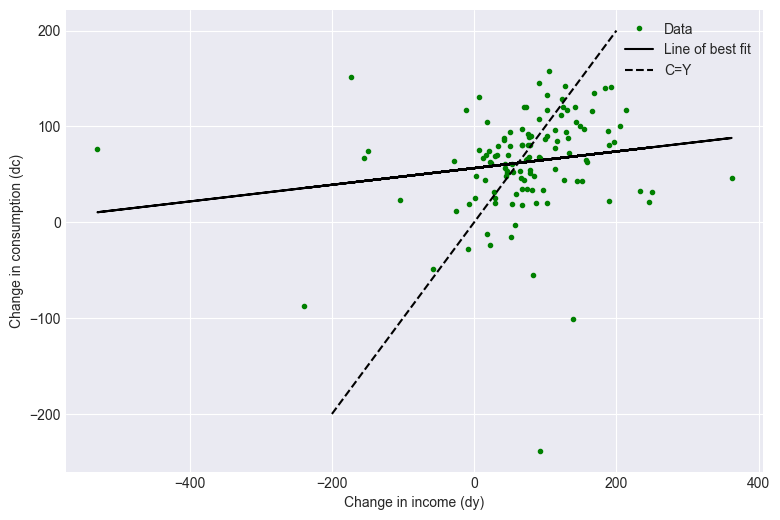

a_1 is 0.09


In [14]:
# Lets use the data from FRED that we used before.

# Using quarterly data (copying from above), we had:

plt.figure(figsize=(9, 6))
plt.plot(df_diff.DPIC96, df_diff.PCECC96, "go", markersize=3.0, label="Data")
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_diff.DPIC96[1:], df_diff.PCECC96[1:]
)  # find line of best fit
plt.plot(
    df_diff.DPIC96[1:],
    intercept + slope * df_diff.DPIC96[1:],
    "k-",
    label="Line of best fit",
)
plt.plot(np.array([-200, 200]), np.array([-200, 200]), "k--", label="C=Y")
plt.xlabel("Change in income (dy)")
plt.ylabel("Change in consumption (dc)")
plt.legend()
plt.show()

print("a_1 is {:.2f}".format(slope))

And now consider longer time differences, 20 quarters for instance, where the changes in permanent income should dominate transitory effects

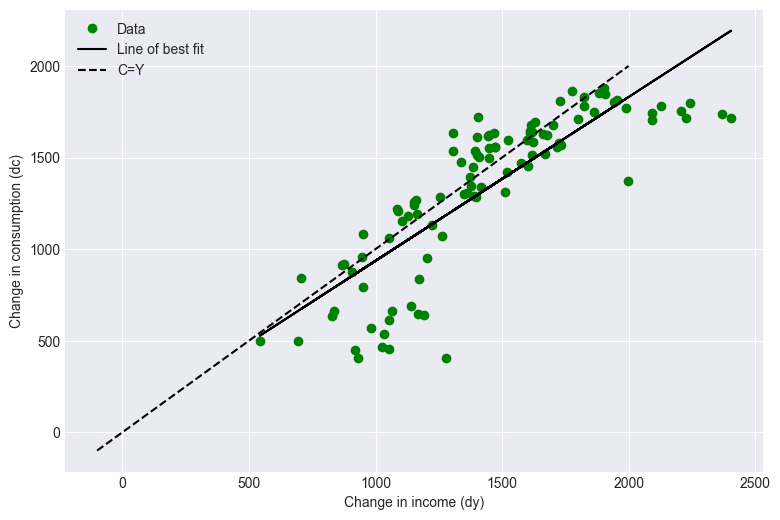

a_0 is 41.76
a_1 is 0.89


In [15]:
# Using longer differences
df_diff_long = df.diff(periods=20)  # create dataframe of differenced values
df_diff_long.columns = ["cons", "inc"]

plt.figure(figsize=(9, 6))
plt.plot(df_diff_long.inc, df_diff_long.cons, "go", label="Data")
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_diff_long.inc[20:], df_diff_long.cons[20:]
)  # find line of best fit
plt.plot(
    df_diff_long.inc[1:],
    intercept + slope * df_diff_long.inc[1:],
    "k-",
    label="Line of best fit",
)
plt.plot(np.linspace(-100, 2000, 3), np.linspace(-100, 2000, 3), "k--", label="C=Y")
plt.legend()
plt.xlabel("Change in income (dy)")
plt.ylabel("Change in consumption (dc)")
plt.show()

print("a_0 is {:.2f}".format(intercept))
print("a_1 is {:.2f}".format(slope))

The estimate of $a_1$ using the longer differences is much higher because permanent income is playing a much more important role in explaining the variation in consumption.

### Assignment: farmers vs workers (non-farmers)

Simulate $n=50$ observations of $y_i$ for **farmers** and **workers**, using the PIH consumer above.

Income is $y_i = p_i\,\xi_i$ with $p_i=\psi_i$ (normalize initial permanent income to 1). Shocks are mean-one lognormals, the HARK convention:

$$
\ln\psi\sim N(-\tfrac12\sigma^2_\psi,\sigma^2_\psi),\qquad
\ln\xi\sim N(-\tfrac12\sigma^2_\xi,\sigma^2_\xi).
$$

Workers: $\{\sigma^2_{\psi,\text{workers}},\sigma^2_{\xi,\text{workers}}\}=\{0.01,0.02\}$.

| Scenario | Farmers relative to workers |
|---|---|
| (a) | $\sigma^2_{\psi,f}=\sigma^2_{\psi,w}$, $\sigma^2_{\xi,f}=3\sigma^2_{\xi,w}$ |
| (b) | $\sigma^2_{\psi,f}=10\sigma^2_{\psi,w}$, $\sigma^2_{\xi,f}=3\sigma^2_{\xi,w}$ |
| (c) | $\sigma^2_{\psi,f}=0.1\sigma^2_{\psi,w}$, $\sigma^2_{\xi,f}=3\sigma^2_{\xi,w}$ |

Under the PIH, $c_i=p_i$. The Keynesian regression $c_i=\alpha_0+\alpha_1 y_i+u_i$ is estimated separately for each group. Plots put $y$ on the horizontal axis and $p$ on the vertical axis (so $c=p$), with a 45-degree $c=y$ line.

Scenario (a):  workers a1=0.326, a0=0.663  |  farmers a1=0.095, a0=0.873
Scenario (b):  workers a1=0.258, a0=0.755  |  farmers a1=0.678, a0=0.401
Scenario (c):  workers a1=0.325, a0=0.668  |  farmers a1=0.009, a0=0.998


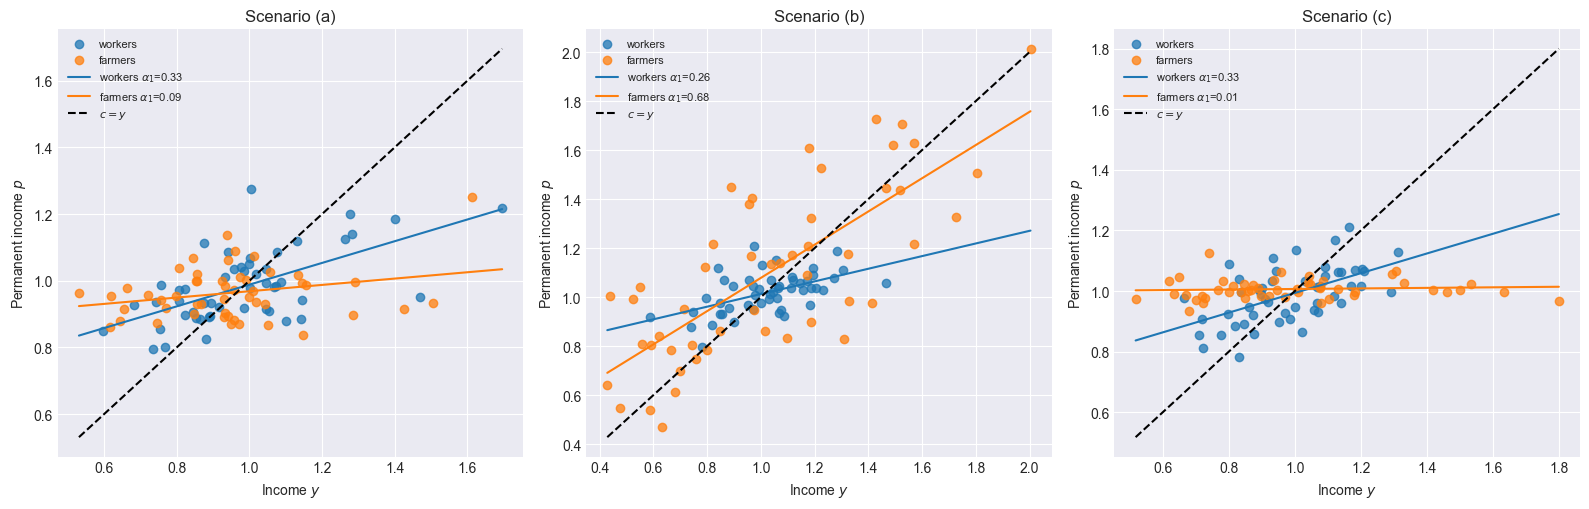

In [16]:
# Farmers vs workers: 50 observations of y_i in scenarios (a), (b), (c)
np.random.seed(9981)
PIHexample = FriedmanPIHConsumer()

n_obs = 50
sig2_psi_workers = 0.01
sig2_xi_workers = 0.02


def simulate_group(sig2_psi, sig2_xi, n=n_obs):
    """Draw p=psi, y=p*xi, and PIH consumption c=cFunc(y/p)*p."""
    log_psi = np.random.normal(-0.5 * sig2_psi, np.sqrt(sig2_psi), n)
    log_xi = np.random.normal(-0.5 * sig2_xi, np.sqrt(sig2_xi), n)
    p = np.exp(log_psi)
    y = p * np.exp(log_xi)
    c = PIHexample.cFunc(y / p) * p
    return y, p, c


scenarios = {
    "a": {"psi_mult": 1.0, "xi_mult": 3.0},
    "b": {"psi_mult": 10.0, "xi_mult": 3.0},
    "c": {"psi_mult": 0.1, "xi_mult": 3.0},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=False)

for ax, (label, spec) in zip(axes, scenarios.items()):
    y_w, p_w, c_w = simulate_group(sig2_psi_workers, sig2_xi_workers)
    y_f, p_f, c_f = simulate_group(
        spec["psi_mult"] * sig2_psi_workers,
        spec["xi_mult"] * sig2_xi_workers,
    )

    a1_w, a0_w, _, _, _ = stats.linregress(y_w, c_w)
    a1_f, a0_f, _, _, _ = stats.linregress(y_f, c_f)

    ax.scatter(y_w, p_w, color="C0", alpha=0.75, label="workers")
    ax.scatter(y_f, p_f, color="C1", alpha=0.75, label="farmers")

    y_grid = np.linspace(
        min(y_w.min(), y_f.min()),
        max(y_w.max(), y_f.max()),
        80,
    )
    ax.plot(y_grid, a0_w + a1_w * y_grid, color="C0", label=f"workers $\\alpha_1$={a1_w:.2f}")
    ax.plot(y_grid, a0_f + a1_f * y_grid, color="C1", label=f"farmers $\\alpha_1$={a1_f:.2f}")
    ax.plot(y_grid, y_grid, "k--", label="$c=y$")

    ax.set_xlabel("Income $y$")
    ax.set_ylabel("Permanent income $p$")
    ax.set_title(f"Scenario ({label})")
    ax.legend(fontsize=8)
    ax.set_aspect("auto")

    print(
        f"Scenario ({label}):  workers a1={a1_w:.3f}, a0={a0_w:.3f}  |  "
        f"farmers a1={a1_f:.3f}, a0={a0_f:.3f}"
    )

plt.tight_layout()
plt.show()

**Discussion.** Friedman’s formula is $\alpha_1=s_p^2/(s_p^2+s_v^2)$: the OLS slope is smaller when transitory noise is large relative to permanent-income variation.

- **(a)** Farmers have the same permanent-shock variance as workers but three times the transitory variance, so farmers’ $\alpha_1$ is lower. The farmer cloud is more spread in $y$ for a given $p$, and the fitted line is flatter — matching the idea that a group with noisier current income looks like a smaller Keynesian MPC.
- **(b)** Farmers also have ten times the permanent-shock variance. Permanent differences now dominate $y$, so farmers’ $\alpha_1$ rises (often above workers). The scatter sits closer to a 45-degree relationship in $p$ vs $y$.
- **(c)** Farmers have *less* permanent variation and still more transitory variation, so almost all of $y$ is noise. Farmers’ $\alpha_1$ is smallest; $p$ is nearly flat in $y$.

The 45-degree line is $c=y$. Under the PIH, $c=p$, so points lie on the $p$ vs $y$ scatter, not on $c=y$, unless $\xi=1$. These graphs support the PIH prediction used in the first part of the question: measured $\alpha_1$ tracks the *share* of income variance that is permanent, not a structural MPC of 1.

### Assignment 2: saving rate at $t$ vs income growth to $t+1$

Observe 50 households in two consecutive periods. Permanent income $p_i$ is fixed from $t$ to $t+1$; only transitory shocks $\xi$ change.

$$
y_{i,t}=p_i\xi_{i,t},\qquad y_{i,t+1}=p_i\xi_{i,t+1},\qquad c_{i,t}=p_i
$$

(using the PIH consumer). Saving rate at $t$ is $(y_{i,t}-c_{i,t})/y_{i,t}$. Income growth is $(y_{i,t+1}-y_{i,t})/y_{i,t}$.

Prediction: a household with a high saving rate at $t$ had a high transitory income. With $p$ fixed, $y$ mean-reverts, so subsequent income growth should be **lower**. The scatter should slope down.

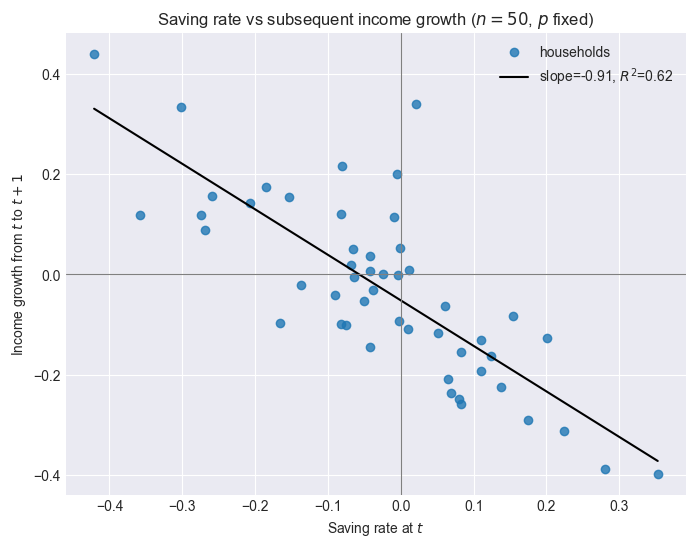

slope = -0.908
intercept = -0.052
corr = -0.790


In [17]:
# Two periods, p fixed: saving rate at t vs income growth t to t+1
np.random.seed(9981)
PIHexample = FriedmanPIHConsumer()

n_obs = 50
sig2_psi = 0.01
sig2_xi = 0.02

log_psi = np.random.normal(-0.5 * sig2_psi, np.sqrt(sig2_psi), n_obs)
p = np.exp(log_psi)

log_xi_t = np.random.normal(-0.5 * sig2_xi, np.sqrt(sig2_xi), n_obs)
log_xi_t1 = np.random.normal(-0.5 * sig2_xi, np.sqrt(sig2_xi), n_obs)
y_t = p * np.exp(log_xi_t)
y_t1 = p * np.exp(log_xi_t1)

c_t = PIHexample.cFunc(y_t / p) * p
saving_rate_t = (y_t - c_t) / y_t
income_growth = (y_t1 - y_t) / y_t

slope, intercept, r_value, p_value, std_err = stats.linregress(
    saving_rate_t, income_growth
)

plt.figure(figsize=(8, 6))
plt.scatter(saving_rate_t, income_growth, color="C0", alpha=0.8, label="households")
x_line = np.linspace(saving_rate_t.min(), saving_rate_t.max(), 50)
plt.plot(
    x_line,
    intercept + slope * x_line,
    "k-",
    label=f"slope={slope:.2f}, $R^2$={r_value**2:.2f}",
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Saving rate at $t$")
plt.ylabel("Income growth from $t$ to $t+1$")
plt.title("Saving rate vs subsequent income growth ($n=50$, $p$ fixed)")
plt.legend()
plt.show()

print(f"slope = {slope:.3f}")
print(f"intercept = {intercept:.3f}")
print(f"corr = {r_value:.3f}")

**Discussion.** Under the PIH, consumption tracks permanent income, so the period-$t$ saving rate is high when current $y_t$ is temporarily above $p$ and low (or negative) when $y_t$ is temporarily below $p$. Because $p$ does not change and $\xi_{t+1}$ is independent of $\xi_t$, a high $y_t$ is typically followed by a lower $y_{t+1}$ (mean reversion). That produces a **negative** relationship between the saving rate at $t$ and income growth from $t$ to $t+1$.

The 50-point graph should slope down, which supports that prediction: high savers are not “thriftier” in a structural sense here; they are households that just received a positive transitory shock.

### Assignment 3: saving rates of Black and white households

Assumptions from the problem:
- every white household has the same permanent income $p_W$
- every Black household has the same permanent income $p_B$, with $p_B$ considerably lower than $p_W$
- both groups get large, similarly sized transitory shocks $\xi$

Under the PIH, $c_i=p_i$ and $y_i=p_i\xi_i$. Saving rate $=(y_i-c_i)/y_i$. Plot saving rates against current income for the two groups.

mean y, white=0.915, Black=0.437
mean c (=p), white=1.000, Black=0.450
mean saving *level* (y-c), white=-0.085, Black=-0.013
mean saving *rate*, white=-0.237, Black=-0.159


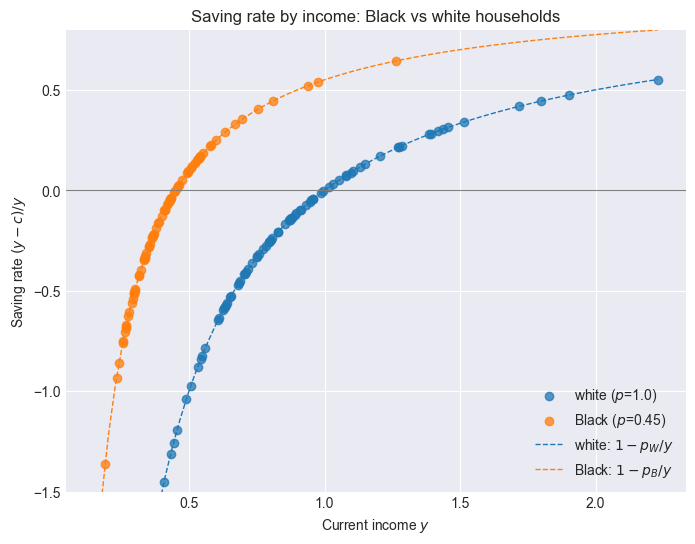

In [18]:
# Black vs white households: same p within group, lower p for Black HHs, large shared transitory shocks
np.random.seed(9981)
PIHexample = FriedmanPIHConsumer()

n_obs = 80
p_white = 1.0
p_black = 0.45
sig2_xi = 0.12

log_xi_w = np.random.normal(-0.5 * sig2_xi, np.sqrt(sig2_xi), n_obs)
log_xi_b = np.random.normal(-0.5 * sig2_xi, np.sqrt(sig2_xi), n_obs)

p_w = np.full(n_obs, p_white)
p_b = np.full(n_obs, p_black)
y_w = p_w * np.exp(log_xi_w)
y_b = p_b * np.exp(log_xi_b)
c_w = PIHexample.cFunc(y_w / p_w) * p_w
c_b = PIHexample.cFunc(y_b / p_b) * p_b
s_w = (y_w - c_w) / y_w
s_b = (y_b - c_b) / y_b

print(f"mean y, white={y_w.mean():.3f}, Black={y_b.mean():.3f}")
print(f"mean c (=p), white={c_w.mean():.3f}, Black={c_b.mean():.3f}")
print(f"mean saving *level* (y-c), white={(y_w-c_w).mean():.3f}, Black={(y_b-c_b).mean():.3f}")
print(f"mean saving *rate*, white={s_w.mean():.3f}, Black={s_b.mean():.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_w, s_w, color="C0", alpha=0.75, label=f"white ($p$={p_white})")
plt.scatter(y_b, s_b, color="C1", alpha=0.75, label=f"Black ($p$={p_black})")
plt.axhline(0, color="gray", linewidth=0.8)
y_grid = np.linspace(0.15, max(y_w.max(), y_b.max()), 80)
plt.plot(y_grid, 1 - p_white / y_grid, "C0--", linewidth=1, label="white: $1-p_W/y$")
plt.plot(y_grid, 1 - p_black / y_grid, "C1--", linewidth=1, label="Black: $1-p_B/y$")
plt.xlabel("Current income $y$")
plt.ylabel("Saving rate $(y-c)/y$")
plt.title("Saving rate by income: Black vs white households")
plt.legend()
plt.ylim(-1.5, 0.8)
plt.show()

**How the PIH reconciles the two facts**

At any given measured income $y$, the two groups are not in the same transitory position:

- White households have high $p_W$. Many whites observed at a moderate $y$ are there because of a negative transitory shock ($y<p_W$), so they dissave.
- Black households have low $p_B$. The same $y$ is at or above their permanent income ($y\ge p_B$), so they save.

That is why, in the figure, the Black cloud sits above the white cloud at a given $y$: $1-p_B/y>1-p_W/y$. This is the same composition effect as farmers vs workers and as the notebook’s remark that Black households save more than whites at a given income.

It does not mean Black households accumulate more wealth. Average saving in *levels* is about the transitory shock, whose mean is zero in both groups. Lifetime resources (and typical wealth) track permanent income. Because $p_B<p_W$, Black households consume less every period ($c=p$) and hold less wealth, even though they look “thriftier” in a cross-section that conditions on current $y$. Whites who appear poor in that cross-section are often only temporarily poor and are running down assets they will rebuild.

### Assignment 4: 1992 withholding change (Bush)

In the 1992 State of the Union, withholding rates were cut but statutory income tax rates were not. Only the *timing* of tax payments changed (more take-home pay during the year, a smaller refund or a balance due later).

Permanent income is the annuity value of nonhuman wealth plus the expected present value of after-tax labor income:

$$
p = \kappa \left( A_t + \sum_{k=0}^{\infty} \frac{\mathbb{E}[y_{t+k}-T_{t+k}]}{(1+R)^k} \right)
$$

where $T$ is taxes and $\kappa$ converts the stock of human-plus-nonhuman wealth into a perpetual flow (e.g. $\kappa=R/(1+R)$ in the infinite-horizon PIH).

The withholding change does not raise lifetime $\sum T$. A dollar less withheld today is a dollar (plus interest) more owed later, so

$$
\Delta\sum_{k=0}^{\infty}\frac{\mathbb{E}[T_{t+k}]}{(1+R)^k}=0 \quad\Rightarrow\quad \Delta p=0.
$$

The extra cash in the paycheck is therefore only a positive transitory shock $\xi_t$ to current disposable income, not a change in $p$. Under the PIH, $c=p$ and transitory income satisfies $\mathbb{E}[\xi]=0$, so that shock is saved, not spent:

$$
\Delta c = \Delta p = 0.
$$

Expected effect on consumption: **none** (or negligible). Households should raise saving while take-home pay is temporarily high, then draw on that saving when the tax is settled later.